In [1]:
#Food Vision Mini Experiment Tracking Project!!
#By: Aurorium Nexus
#Date: 2025-09-22
# For this notebook to run with updated APIs, we need torch 1.12+ and torchvision 0.13+
try:
    import torch
    import torchvision
    assert int(torch.__version__.split(".")[1]) >= 12, "torch version should be 1.12+"
    assert int(torchvision.__version__.split(".")[1]) >= 13, "torchvision version should be 0.13+"
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")
except:
    print(f"[INFO] torch/torchvision versions not as required, installing nightly versions.")
    !pip3 install -U torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cu113
    import torch
    import torchvision
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")



[INFO] torch/torchvision versions not as required, installing nightly versions.
Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu113
torch version: 2.8.0+cpu
torchvision version: 0.23.0+cpu


In [2]:
# Continue with regular imports
import matplotlib.pyplot as plt
import torch
import torchvision

from torch import nn
from torchvision import transforms

# Try to get torchinfo, install it if it doesn't work
try:
    from torchinfo import summary
except:
    print("[INFO] Couldn't find torchinfo... installing it.")
    !pip install -q torchinfo
    from torchinfo import summary

# Try to import the going_modular directory, download it from GitHub if it doesn't work
try:
    from going_modular.going_modular import data_setup, engine
except:
    # Get the going_modular scripts
    print("[INFO] Couldn't find going_modular scripts... downloading them from GitHub.")
    !git clone https://github.com/mrdbourke/pytorch-deep-learning
    !mv pytorch-deep-learning/going_modular .
    !rm -rf pytorch-deep-learning
    from going_modular.going_modular import data_setup, engine

/home/lenovo/Documents/ml_dl_frame_work/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [4]:
def set_seeds(seed : int=42):
    """Sets the random seed for reproducibility."""
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

In [5]:
import os
import zipfile

from pathlib import Path

import requests

def download_data(source: str, 
                  destination: str,
                  remove_source: bool = True) -> Path:
    """Downloads a zipped dataset from source and unzips to destination.

    Args:
        source (str): A link to a zipped file containing data.
        destination (str): A target directory to unzip data to.
        remove_source (bool): Whether to remove the source after downloading and extracting.
    
    Returns:
        pathlib.Path to downloaded data.
    
    Example usage:
        download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip",
                      destination="pizza_steak_sushi")
    """
    # Setup path to data folder
    data_path = Path("data/")
    image_path = data_path / destination

    # If the image folder doesn't exist, download it and prepare it... 
    if image_path.is_dir():
        print(f"[INFO] {image_path} directory exists, skipping download.")
    else:
        print(f"[INFO] Did not find {image_path} directory, creating one...")
        image_path.mkdir(parents=True, exist_ok=True)
        
        # Download pizza, steak, sushi data
        target_file = Path(source).name
        with open(data_path / target_file, "wb") as f:
            request = requests.get(source)
            print(f"[INFO] Downloading {target_file} from {source}...")
            f.write(request.content)

        # Unzip pizza, steak, sushi data
        with zipfile.ZipFile(data_path / target_file, "r") as zip_ref:
            print(f"[INFO] Unzipping {target_file} data...") 
            zip_ref.extractall(image_path)

        # Remove .zip file
        if remove_source:
            os.remove(data_path / target_file)
    
    return image_path

image_path = download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip",
                           destination="pizza_steak_sushi")
image_path

[INFO] data/pizza_steak_sushi directory exists, skipping download.


PosixPath('data/pizza_steak_sushi')

In [6]:
# Manual Tranforms way of doing shit!!

train_dir = image_path / "train"
test_dir = image_path / "test"

normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])

manual_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    normalize
])
print(f"[INFO] Manual transforms: {manual_transforms}")

train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    transform=manual_transforms,
    batch_size=32
)   
train_dataloader, test_dataloader, class_names

[INFO] Manual transforms: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


(<torch.utils.data.dataloader.DataLoader at 0x7e45b42412e0>,
 ['pizza', 'steak', 'sushi'])

In [7]:
#Automatic Way of it !!

train_dir = image_path / "train"    
test_dir = image_path /"test"

weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT


automatic_transforms = weights.transforms()
print(f"Automatically created transform : {automatic_transforms}")
train_dataloader,test_dataloader,class_names = data_setup.create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    transform=automatic_transforms,
    batch_size=32
)   
train_dataloader, test_dataloader, class_names


Automatically created transform : ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)


(<torch.utils.data.dataloader.DataLoader at 0x7e45b407f830>,
 ['pizza', 'steak', 'sushi'])

In [8]:
weights=torchvision.models.EfficientNet_B0_Weights.DEFAULT
model = torchvision.models.efficientnet_b0(weights=weights).to("cpu")

In [9]:
for param in model.features.parameters():
    param.requires_grad = False

#set_seeds(int=42)

model.classifier = torch.nn.Sequential(
    nn.Dropout(p=0.2, inplace=True),
    nn.Linear(in_features=1280, out_features=len(class_names), bias=True)
).to("cpu")

In [10]:
from torchinfo import summary
summary(model,
        input_size=(32, 3, 224, 224), # make sure this is "input_size", not "input_shape" (batch_size, color_channels, height, width)
        verbose=0,
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
)

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                                      [32, 3, 224, 224]    [32, 1280, 7, 7]     --                   False
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]    [32, 32, 112, 112]   --                   False
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]    [32, 32, 112, 112]   (864)                False
│    │    └─BatchNorm2d (1)                                  [32, 32, 112, 112]   [32, 32, 112, 112]   (64)                 False
│    │    └─SiLU (2)                                         [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
│    └─Sequential (1)                                        [32, 32, 112, 112]   [32, 

In [11]:
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [12]:
try:
    from torch.utils.tensorboard import SummaryWriter
except:
    print("[INFO] Couldn't find tensorboard... installing it.")
    !pip install -q tensorboard
    from torch.utils.tensorboard import SummaryWriter


# Create a writer with all default settings
writer = SummaryWriter()

In [13]:
from typing import Dict, List
from tqdm.auto import tqdm

from going_modular.going_modular.engine import train_step, test_step

# Import train() function from: 
# https://github.com/mrdbourke/pytorch-deep-learning/blob/main/going_modular/going_modular/engine.py
def train(model: torch.nn.Module, 
          train_dataloader: torch.utils.data.DataLoader, 
          test_dataloader: torch.utils.data.DataLoader, 
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module,
          epochs: int,
          device: torch.device) -> Dict[str, List]:
    """Trains and tests a PyTorch model.

    Passes a target PyTorch models through train_step() and test_step()
    functions for a number of epochs, training and testing the model
    in the same epoch loop.

    Calculates, prints and stores evaluation metrics throughout.

    Args:
      model: A PyTorch model to be trained and tested.
      train_dataloader: A DataLoader instance for the model to be trained on.
      test_dataloader: A DataLoader instance for the model to be tested on.
      optimizer: A PyTorch optimizer to help minimize the loss function.
      loss_fn: A PyTorch loss function to calculate loss on both datasets.
      epochs: An integer indicating how many epochs to train for.
      device: A target device to compute on (e.g. "cuda" or "cpu").
      
    Returns:
      A dictionary of training and testing loss as well as training and
      testing accuracy metrics. Each metric has a value in a list for 
      each epoch.
      In the form: {train_loss: [...],
                train_acc: [...],
                test_loss: [...],
                test_acc: [...]} 
      For example if training for epochs=2: 
              {train_loss: [2.0616, 1.0537],
                train_acc: [0.3945, 0.3945],
                test_loss: [1.2641, 1.5706],
                test_acc: [0.3400, 0.2973]} 
    """
    # Create empty results dictionary
    results = {"train_loss": [],
               "train_acc": [],
               "test_loss": [],
               "test_acc": []
    }

    # Loop through training and testing steps for a number of epochs
    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer,
                                           device=device)
        test_loss, test_acc = test_step(model=model,
                                        dataloader=test_dataloader,
                                        loss_fn=loss_fn,
                                        device=device)

        # Print out what's happening
        print(
          f"Epoch: {epoch+1} | "
          f"train_loss: {train_loss:.4f} | "
          f"train_acc: {train_acc:.4f} | "
          f"test_loss: {test_loss:.4f} | "
          f"test_acc: {test_acc:.4f}"
        )

        # Update results dictionary
        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)

        ### New: Experiment tracking ###
        # Add loss results to SummaryWriter
        writer.add_scalars(main_tag="Loss", 
                           tag_scalar_dict={"train_loss": train_loss,
                                            "test_loss": test_loss},
                           global_step=epoch)

        # Add accuracy results to SummaryWriter
        writer.add_scalars(main_tag="Accuracy", 
                           tag_scalar_dict={"train_acc": train_acc,
                                            "test_acc": test_acc}, 
                           global_step=epoch)
        
        # Track the PyTorch model architecture
        writer.add_graph(model=model, 
                         # Pass in an example input
                         input_to_model=torch.randn(32, 3, 224, 224).to(device))
    
    # Close the writer
    writer.close()
    
    ### End new ###

    # Return the filled results at the end of the epochs
    return results



In [14]:
set_seeds()
results = train(model=model,
                      train_dataloader=train_dataloader,
                      test_dataloader=test_dataloader,
                      optimizer=optimizer,
                      loss_fn=loss_fn,
                      epochs=10,
                      device=device)

  0%|          | 0/10 [00:00<?, ?it/s]/home/lenovo/Documents/ml_dl_frame_work/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch: 1 | train_loss: 1.1264 | train_acc: 0.3516 | test_loss: 0.8562 | test_acc: 0.7121


 10%|█         | 1/10 [00:22<03:25, 22.78s/it]

Epoch: 2 | train_loss: 0.9078 | train_acc: 0.6406 | test_loss: 0.7995 | test_acc: 0.8049


 20%|██        | 2/10 [00:44<02:56, 22.12s/it]

...

 80%|████████  | 8/10 [02:54<00:43, 21.88s/it]

Epoch: 9 | train_loss: 0.5719 | train_acc: 0.7773 | test_loss: 0.4997 | test_acc: 0.8352


 90%|█████████ | 9/10 [03:15<00:21, 21.56s/it]

Epoch: 10 | train_loss: 0.4821 | train_acc: 0.8242 | test_loss: 0.4844 | test_acc: 0.8248


100%|██████████| 10/10 [03:38<00:00, 21.83s/it]


In [15]:
results

{'train_loss': [1.126397281885147,
  0.9077703207731247,
  0.7590796798467636,
  0.7704779282212257,
  0.6282379664480686,
  0.6142924912273884,
  0.5592518262565136,
  0.52325339615345,
  0.5719200111925602,
  0.4820723459124565],
 'train_acc': [0.3515625,
  0.640625,
  0.84765625,
  0.71484375,
  0.78515625,
  0.80078125,
  0.796875,
  0.91015625,
  0.77734375,
  0.82421875],
 'test_loss': [0.8561606208483378,
  0.7994610667228699,
  0.7461840113004049,
  0.699375331401825,
  0.6442983349164327,
  0.6163751284281412,
  0.5209493239720663,
  0.5409661630789439,
  0.49966885646184284,
  0.48441531260808307],
 'test_acc': [0.712121212121212,
  0.8049242424242425,
  0.7537878787878788,
  0.743371212121212,
  0.8248106060606061,
  0.8049242424242425,
  0.8456439393939394,
  0.8768939393939394,
  0.8352272727272728,
  0.8248106060606061]}

In [16]:
# Example code to run in Jupyter or Google Colab Notebook (uncomment to try it out)
%load_ext tensorboard
%tensorboard --logdir runs

Launching TensorBoard...

In [17]:
def create_writer(experiment_name : str,
                  model_name:str,
                  extra:str=None) -> torch.utils.tensorboard.SummaryWriter:
    
    from datetime import datetime
    import os

    timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
    if extra:
        log_dir = os.path.join("runs", experiment_name, model_name, extra, timestamp)
    else:
        log_dir = os.path.join("runs", experiment_name, model_name, timestamp)
    print(f"[INFO] Created log directory at: {log_dir}")
    return SummaryWriter(log_dir=log_dir)   

In [18]:
example_writer = create_writer(experiment_name="data_10_percent",
                                model_name="effnetb0",
                                extra="5_epochs")

[INFO] Created log directory at: runs/data_10_percent/effnetb0/5_epochs/20250929-232603


In [19]:
from typing import Dict, List, Tuple
from tqdm.auto import tqdm
def train(model: torch.nn.Module,   
          train_dataloader: torch.utils.data.DataLoader, 
          test_dataloader: torch.utils.data.DataLoader, 
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module,
 #         epochs: int,
          device: torch.device,
          writer:torch.utils.tensorboard.writer.SummaryWriter) -> Dict[str, List]:
    

    
    
    results = {"train_loss": [],
           "train_acc": [],
           "test_loss": [],
           "test_acc": []
           }

for epoch in tqdm(range(10)):
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer,
                                           device=device)
        test_loss, test_acc = test_step(model=model,
                                        dataloader=test_dataloader,
                                        loss_fn=loss_fn,
                                        device=device)

        print(
          f"Epoch: {epoch+1} | "
          f"train_loss: {train_loss:.4f} | "
          f"train_acc: {train_acc:.4f} | "
          f"test_loss: {test_loss:.4f} | "
          f"test_acc: {test_acc:.4f}"
        )

        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)

        if writer:
                
                writer.add_scalars(main_tag="Loss", 
                           tag_scalar_dict={"train_loss": train_loss,
                                            "test_loss": test_loss},
                           global_step=epoch)
                writer.add_scalars(main_tag="Accuracy", 
                           tag_scalar_dict={"train_acc": train_acc,
                                            "test_acc": test_acc}, 
                           global_step=epoch)
        
                writer.close()
        else:
            pass


          

    

  0%|          | 0/10 [00:00<?, ?it/s]/home/lenovo/Documents/ml_dl_frame_work/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
 10%|█         | 1/10 [00:14<02:12, 14.71s/it]

Epoch: 1 | train_loss: 0.5194 | train_acc: 0.8281 | test_loss: 0.5071 | test_acc: 0.8352


 20%|██        | 2/10 [00:29<01:59, 14.90s/it]

Epoch: 2 | train_loss: 0.4512 | train_acc: 0.8359 | test_loss: 0.4527 | test_acc: 0.8561


 30%|███       | 3/10 [00:43<01:41, 14.47s/it]

...

Epoch: 8 | train_loss: 0.3669 | train_acc: 0.8359 | test_loss: 0.3808 | test_acc: 0.8561


 90%|█████████ | 9/10 [02:08<00:13, 13.98s/it]

Epoch: 9 | train_loss: 0.3885 | train_acc: 0.8320 | test_loss: 0.4271 | test_acc: 0.8352


100%|██████████| 10/10 [02:22<00:00, 14.23s/it]

Epoch: 10 | train_loss: 0.3180 | train_acc: 0.9688 | test_loss: 0.4163 | test_acc: 0.8352


In [20]:
results

{'train_loss': [1.126397281885147,
  0.9077703207731247,
  0.7590796798467636,
  0.7704779282212257,
  0.6282379664480686,
  0.6142924912273884,
  0.5592518262565136,
  0.52325339615345,
  0.5719200111925602,
  0.4820723459124565,
  0.5193611271679401,
  0.45118092373013496,
  0.4119060393422842,
  0.3808780312538147,
  0.5016243122518063,
  0.4331609886139631,
  0.4653820227831602,
  0.36689694598317146,
  0.3885067142546177,
  0.31797516345977783],
 'train_acc': [0.3515625,
  0.640625,
  0.84765625,
  0.71484375,
  0.78515625,
  0.80078125,
  0.796875,
  0.91015625,
  0.77734375,
  0.82421875,
  0.828125,
  0.8359375,
  0.8359375,
  0.94140625,
  0.8203125,
  0.84375,
  0.81640625,
  0.8359375,
  0.83203125,
  0.96875],
 'test_loss': [0.8561606208483378,
  0.7994610667228699,
  0.7461840113004049,
  0.699375331401825,
  0.6442983349164327,
  0.6163751284281412,
  0.5209493239720663,
  0.5409661630789439,
  0.49966885646184284,
  0.48441531260808307,
  0.5071487426757812,
  0.45268273

In [21]:
#
data_10_percent_path = download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip",
                                     destination="pizza_steak_sushi")

data_20_percent_path = download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi_20_percent.zip",
                                     destination="pizza_steak_sushi_20_percent")

[INFO] data/pizza_steak_sushi directory exists, skipping download.
[INFO] data/pizza_steak_sushi_20_percent directory exists, skipping download.


In [22]:

train_dir_10_percent = data_10_percent_path / "train"
train_dir_20_percent = data_20_percent_path / "train"


test_dir = data_10_percent_path / "test"


print(f"Training directory 10%: {train_dir_10_percent}")
print(f"Training directory 20%: {train_dir_20_percent}")
print(f"Testing directory: {test_dir}")

Training directory 10%: data/pizza_steak_sushi/train
Training directory 20%: data/pizza_steak_sushi_20_percent/train
Testing directory: data/pizza_steak_sushi/test


In [23]:
from torchvision import transforms  

normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])

simple_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    normalize
])


In [24]:
BATCH_SIZE = 32

train_dataloader_10_percent, test_dataloader, class_names = data_setup.create_dataloaders(
    train_dir=train_dir_10_percent,
    test_dir=test_dir,
    transform=simple_transforms,
    batch_size=BATCH_SIZE
)   
train_dataloader_20_percent, _, _ = data_setup.create_dataloaders(
    train_dir=train_dir_20_percent,
    test_dir=test_dir,
    transform=simple_transforms,
    batch_size=BATCH_SIZE
)
print(f"Batch size for {BATCH_SIZE} for 10% dataloaders : {len(train_dataloader_10_percent)}")
print(f"Batch size for {BATCH_SIZE} for 20% dataloaders : {len(train_dataloader_20_percent)}")
print(f"Batch size for {BATCH_SIZE} for test dataloaders : {len(test_dataloader)} ")
print(f"Class names : {class_names}")

Batch size for 32 for 10% dataloaders : 8
Batch size for 32 for 20% dataloaders : 15
Batch size for 32 for test dataloaders : 3 
Class names : ['pizza', 'steak', 'sushi']


In [25]:
import torchvision
from torchinfo import summary


effnetb2_weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT # "DEFAULT" means best available weights
effnetb2 = torchvision.models.efficientnet_b2(weights=effnetb2_weights)

# 2. Get a summary of standard EffNetB2 from torchvision.models (uncomment for full output)

summary(model=effnetb2, 
        input_size=(32, 3, 224, 224), # make sure this is "input_size", not "input_shape"
        
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
 ) 


# 3. Get the number of in_features of the EfficientNetB2 classifier layer
print(f"Number of in_features to final layer of EfficientNetB2: {len(effnetb2.classifier.state_dict()['1.weight'][0])}")

Number of in_features to final layer of EfficientNetB2: 1408


In [28]:
import torchvision
from torch import nn

OUT_FEATURES = len(class_names)

def create_effnetb0():
    weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT
    model = torchvision.models.efficientnet_b0(weights=weights).to(device)

    for param in model.features.parameters():
        param.requires_grad = False

    set_seeds()

    model.classifier = torch.nn.Sequential(
        nn.Dropout(p=0.2),
        nn.Linear(in_features=1280, out_features=OUT_FEATURES)
    ).to(device)
    
    model.name = "effnetb0"
    print(f"[INFO] Created {model.name} model.")
    return model

def create_effnetb2():
    weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT
    model = torchvision.models.efficientnet_b2(weights=weights).to(device)

    for param in model.features.parameters():
        param.requires_grad = False

    set_seeds()

    model.classifier = torch.nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features=1408, out_features=OUT_FEATURES)
    ).to(device)
    
    model.name = "effnetb2"
    print(f"[INFO] Created {model.name} model.")
    return model

In [29]:
effnetb0 = create_effnetb0()

[INFO] Created effnetb0 model.


In [30]:
effnetb2 = create_effnetb2()

[INFO] Created effnetb2 model.


In [31]:
num_epochs = [5, 10]
models = [effnetb0, effnetb2]
train_dataloaders = { "data_10_percent": train_dataloader_10_percent, "data_20_percent": train_dataloader_20_percent }

In [34]:
from going_modular.going_modular.utils import save_model

set_seeds(seed=42)

experiment_number =0

for dataloader_name , train_dataloader in train_dataloaders.items():
    
    for epochs in num_epochs:
        for model in models:
            experiment_number +=1
            print(f"[INFO] Starting experiment number: {experiment_number}")
            print(f"[INFO] Model:{model.name}")
            print(f"[INFO] Dataloader: {dataloader_name}")
            print(f"[INFO] Epochs: {epochs}")

            if model.name == "effnetb0":
                model = create_effnetb0()
            else:
                model = create_effnetb2()

            loss_fn=nn.CrossEntropyLoss()
            optimizer=torch.optim.Adam(model.parameters(), lr=0.001)

            train(model=model,
                  train_dataloader=train_dataloader,
                  test_dataloader=test_dataloader,
                  optimizer=optimizer,
                  loss_fn=loss_fn,
                  device=device,
                  writer=create_writer(experiment_name=dataloader_name,
                                       model_name=model.name,
                                       extra=f"{epochs}_epochs")
                  )

            save_filepath =f"07_{model.name}_{dataloader_name}_{epochs}_epochs.pth"
            save_model(model=model,
                       target_dir="models",
                       model_name=save_filepath)
            print("-" * 50+ "\n")

[INFO] Starting experiment number: 1
[INFO] Model:effnetb0
[INFO] Dataloader: data_10_percent
[INFO] Epochs: 5
[INFO] Created effnetb0 model.
[INFO] Created log directory at: runs/data_10_percent/effnetb0/5_epochs/20250929-234407
[INFO] Saving model to: models/07_effnetb0_data_10_percent_5_epochs.pth
--------------------------------------------------

[INFO] Starting experiment number: 2
[INFO] Model:effnetb2
[INFO] Dataloader: data_10_percent
[INFO] Epochs: 5
[INFO] Created effnetb2 model.
[INFO] Created log directory at: runs/data_10_percent/effnetb2/5_epochs/20250929-234408
[INFO] Saving model to: models/07_effnetb2_data_10_percent_5_epochs.pth
--------------------------------------------------

[INFO] Starting experiment number: 3
[INFO] Model:effnetb0
[INFO] Dataloader: data_10_percent
[INFO] Epochs: 10
[INFO] Created effnetb0 model.
[INFO] Created log directory at: runs/data_10_percent/effnetb0/10_epochs/20250929-234408
[INFO] Saving model to: models/07_effnetb0_data_10_percent_1

In [36]:
%load_ext tensorboard
%tensorboard --logdir runs

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 103471), started 0:20:15 ago. (Use '!kill 103471' to kill it.)

In [37]:
best_model_path = Path("models/07_effnetb2_data_20_percent_10_epochs.pth")
best_model = create_effnetb2()
best_model.load_state_dict(torch.load(best_model_path))


[INFO] Created effnetb2 model.


<All keys matched successfully>

In [38]:
from pathlib import Path

effnetb2_model_size = Path(best_model_path).stat().st_size // (1024 * 1024)
print(f"EfficientNetB2 model size: {effnetb2_model_size} MB")

EfficientNetB2 model size: 29 MB


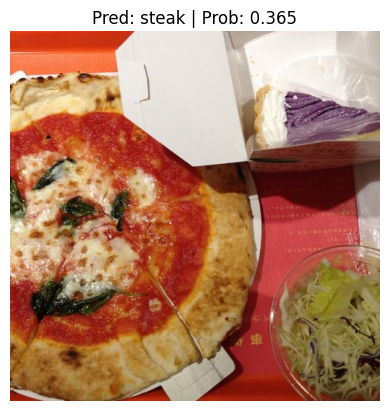

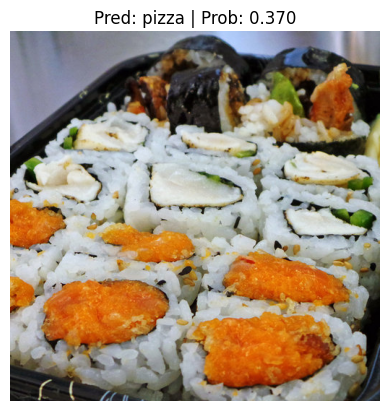

In [46]:
from going_modular.going_modular.predictions import  pred_and_plot_image

import random
num_images_to_plot = 2
test_image_path_list = list(Path(data_20_percent_path/"test").glob("*/*.jpg"))
test_image_path_sample = random.sample(population=test_image_path_list, k=num_images_to_plot)

for img_path in test_image_path_sample:
    pred_and_plot_image(model= best_model,
                        image_path=img_path,
                        class_names=class_names,image_size=(224,224))

data/04-pizza-dad.jpeg already exists, skipping download.


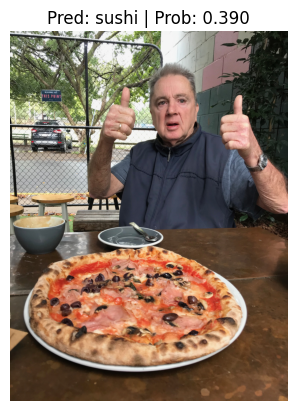

In [48]:
# Download custom image
import requests

# Setup custom image path
custom_image_path = Path("data/04-pizza-dad.jpeg")

# Download the image if it doesn't already exist
if not custom_image_path.is_file():
    with open(custom_image_path, "wb") as f:
        # When downloading from GitHub, need to use the "raw" file link
        request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/04-pizza-dad.jpeg")
        print(f"Downloading {custom_image_path}...")
        f.write(request.content)
else:
    print(f"{custom_image_path} already exists, skipping download.")

# Predict on custom image
pred_and_plot_image(model=model,
                    image_path=custom_image_path,
                    class_names=class_names)